# Previsão de Rotatividade de Funcionários (Attrition)

*Comparação de regressão logística, random forest, XGBoost e rede neural sob desbalanceamento de classes*

---

Autor: Wellington Moreira

Contato: https://www.linkedin.com/in/wellington-moreira-santos/

E-mail: wsantos08@hotmail.com

## Introdução

Empresas enfrentam custos elevados de contratação e treinamento quando funcionários deixam a organização sem aviso estratégico. Neste projeto, construo um modelo de classificação para prever a rotatividade (attrition) de funcionários a partir do dataset IBM HR Analytics Employee Attrition, disponibilizado no Kaggle, utilizado originalmente no estudo de caso de Recursos Humanos do curso Ciência de Dados para Empresas e Negócios (IAExpert Academy).

O material original do curso treina três modelos (regressão logística, random forest e rede neural) avaliando apenas por acurácia, sem fixar `random_state` ou usar `stratify` na divisão treino/teste, e sem tratar o desbalanceamento das classes, que neste dataset gira em torno de 16% de funcionários que saíram contra 84% que permaneceram. Isso compromete a reprodutibilidade dos resultados e mascara o desempenho real do modelo na classe minoritária, que é a que mais interessa ao negócio.

Neste projeto, expando o escopo original em três frentes. Primeiro, trato o desbalanceamento de classes de forma explícita, comparando cada modelo com e sem ponderação de classes. Segundo, adiciono XGBoost como quarto modelo e uso validação cruzada estratificada para tornar a comparação entre os quatro modelos mais robusta que uma única divisão treino/teste. Terceiro, interpreto os fatores mais relevantes para a previsão cruzando coeficientes da regressão logística com a importância de variáveis de random forest e XGBoost, verificando se os modelos convergem para os mesmos fatores de risco.

As principais ferramentas utilizadas são pandas, numpy, scikit-learn, xgboost, tensorflow/keras, matplotlib e seaborn.

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Tratamento e Limpeza dos Dados
5. Preparação para o Modelo
6. Treinamento dos Modelos
7. Avaliação dos Modelos
8. Conclusão e Considerações Finais
9. Referências

## 1. Imports e Configurações

In [3]:
!pip install xgboost tensorflow -q

### 1.1 Importações

In [26]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier
import tensorflow as tf

import session_info

### 1.2 Configurações Globais

In [27]:
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

session_info.show(dependencies=False)

## 2. Coleta e Inspeção dos Dados

### 2.1 Carregamento

In [18]:
try:
    employee_df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print('- DADOS CARREGADOS -')
except FileNotFoundError: print('Erro ao carregar arquivo, verifique o caminho.')
except Exception as e: print(f'Erro: {str(e)} ')

- DADOS CARREGADOS -


### 2.2 Visão Geral

In [8]:
# primeiros registros
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
# dimensoes
employee_df.shape

(1470, 35)

In [10]:
# tipo de dados
employee_df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [12]:
# nulos 
employee_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### 2.3 Estatísticas Descritivas

In [14]:
employee_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [15]:
# distribuição do attr alvo
employee_df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## 3. Análise Exploratória

### 3.1 Colunas constantes e irrelevantes

Verifico a cardinalidade de colunas suspeitas de serem constantes ou identificadoras, que não agregam informação ao modelo.

In [16]:
employee_df[['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']].nunique()

EmployeeCount        1
StandardHours        1
Over18               1
EmployeeNumber    1470
dtype: int64

### 3.2 Correlação com a variável alvo

Para esta análise exploratória, uso uma cópia numérica temporária de Attrition. A codificação oficial da coluna ocorre na Seção 4.

In [17]:
correlacao_exploratoria = employee_df.copy()
correlacao_exploratoria['Attrition'] = correlacao_exploratoria['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
correlacao_exploratoria.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
N

### 3.3 Multicolinearidade entre variáveis numéricas

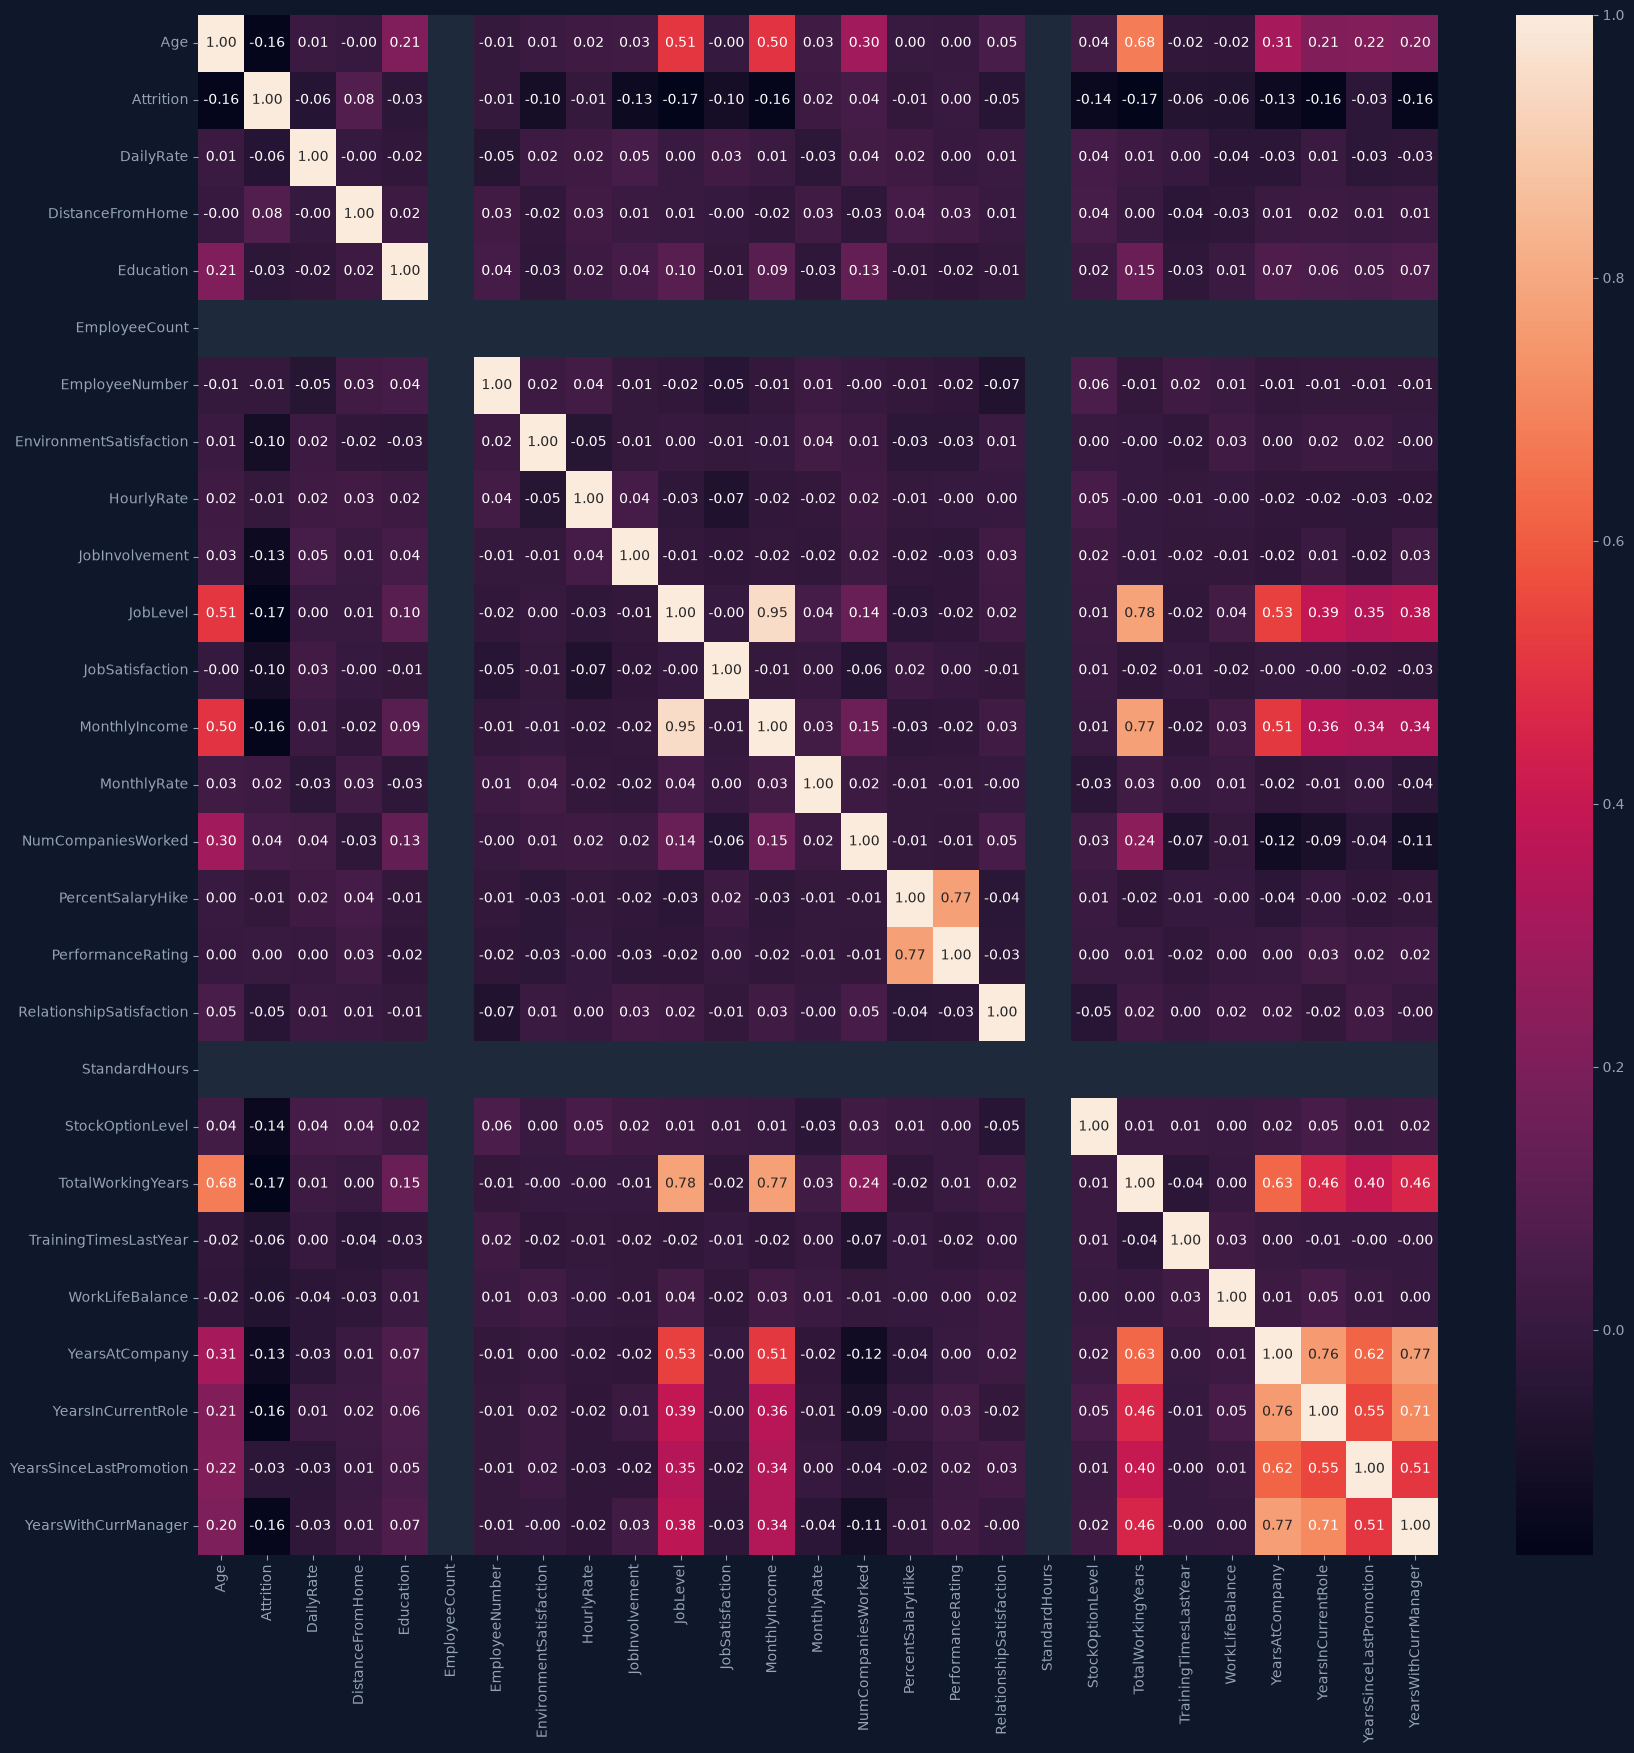

In [18]:
f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(correlacao_exploratoria.corr(numeric_only=True), annot=True, fmt='.2f', ax=ax)
plt.show()

In [42]:
pares = correlacao_exploratoria.corr(numeric_only=True).unstack()
pares

Age                   Age                        1.000000
                      Attrition                 -0.159205
                      DailyRate                  0.010661
                      DistanceFromHome          -0.001686
                      Education                  0.208034
                                                   ...   
YearsWithCurrManager  WorkLifeBalance            0.002759
                      YearsAtCompany             0.769212
                      YearsInCurrentRole         0.714365
                      YearsSinceLastPromotion    0.510224
                      YearsWithCurrManager       1.000000
Length: 729, dtype: float64

In [43]:
alta_correlacao = pares[(pares > .6) & (pares < 1.0)]
alta_correlacao

Age                      TotalWorkingYears          0.680381
JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
MonthlyIncome            JobLevel                   0.950300
                         TotalWorkingYears          0.772893
PercentSalaryHike        PerformanceRating          0.773550
PerformanceRating        PercentSalaryHike          0.773550
TotalWorkingYears        Age                        0.680381
                         JobLevel                   0.782208
                         MonthlyIncome              0.772893
                         YearsAtCompany             0.628133
YearsAtCompany           TotalWorkingYears          0.628133
                         YearsInCurrentRole         0.758754
                         YearsSinceLastPromotion    0.618409
                         YearsWithCurrManager       0.769212
YearsInCurrentRole       YearsAtCompany             0.758754
                        

### 3.4 Perfil comportamental por variáveis categóricas

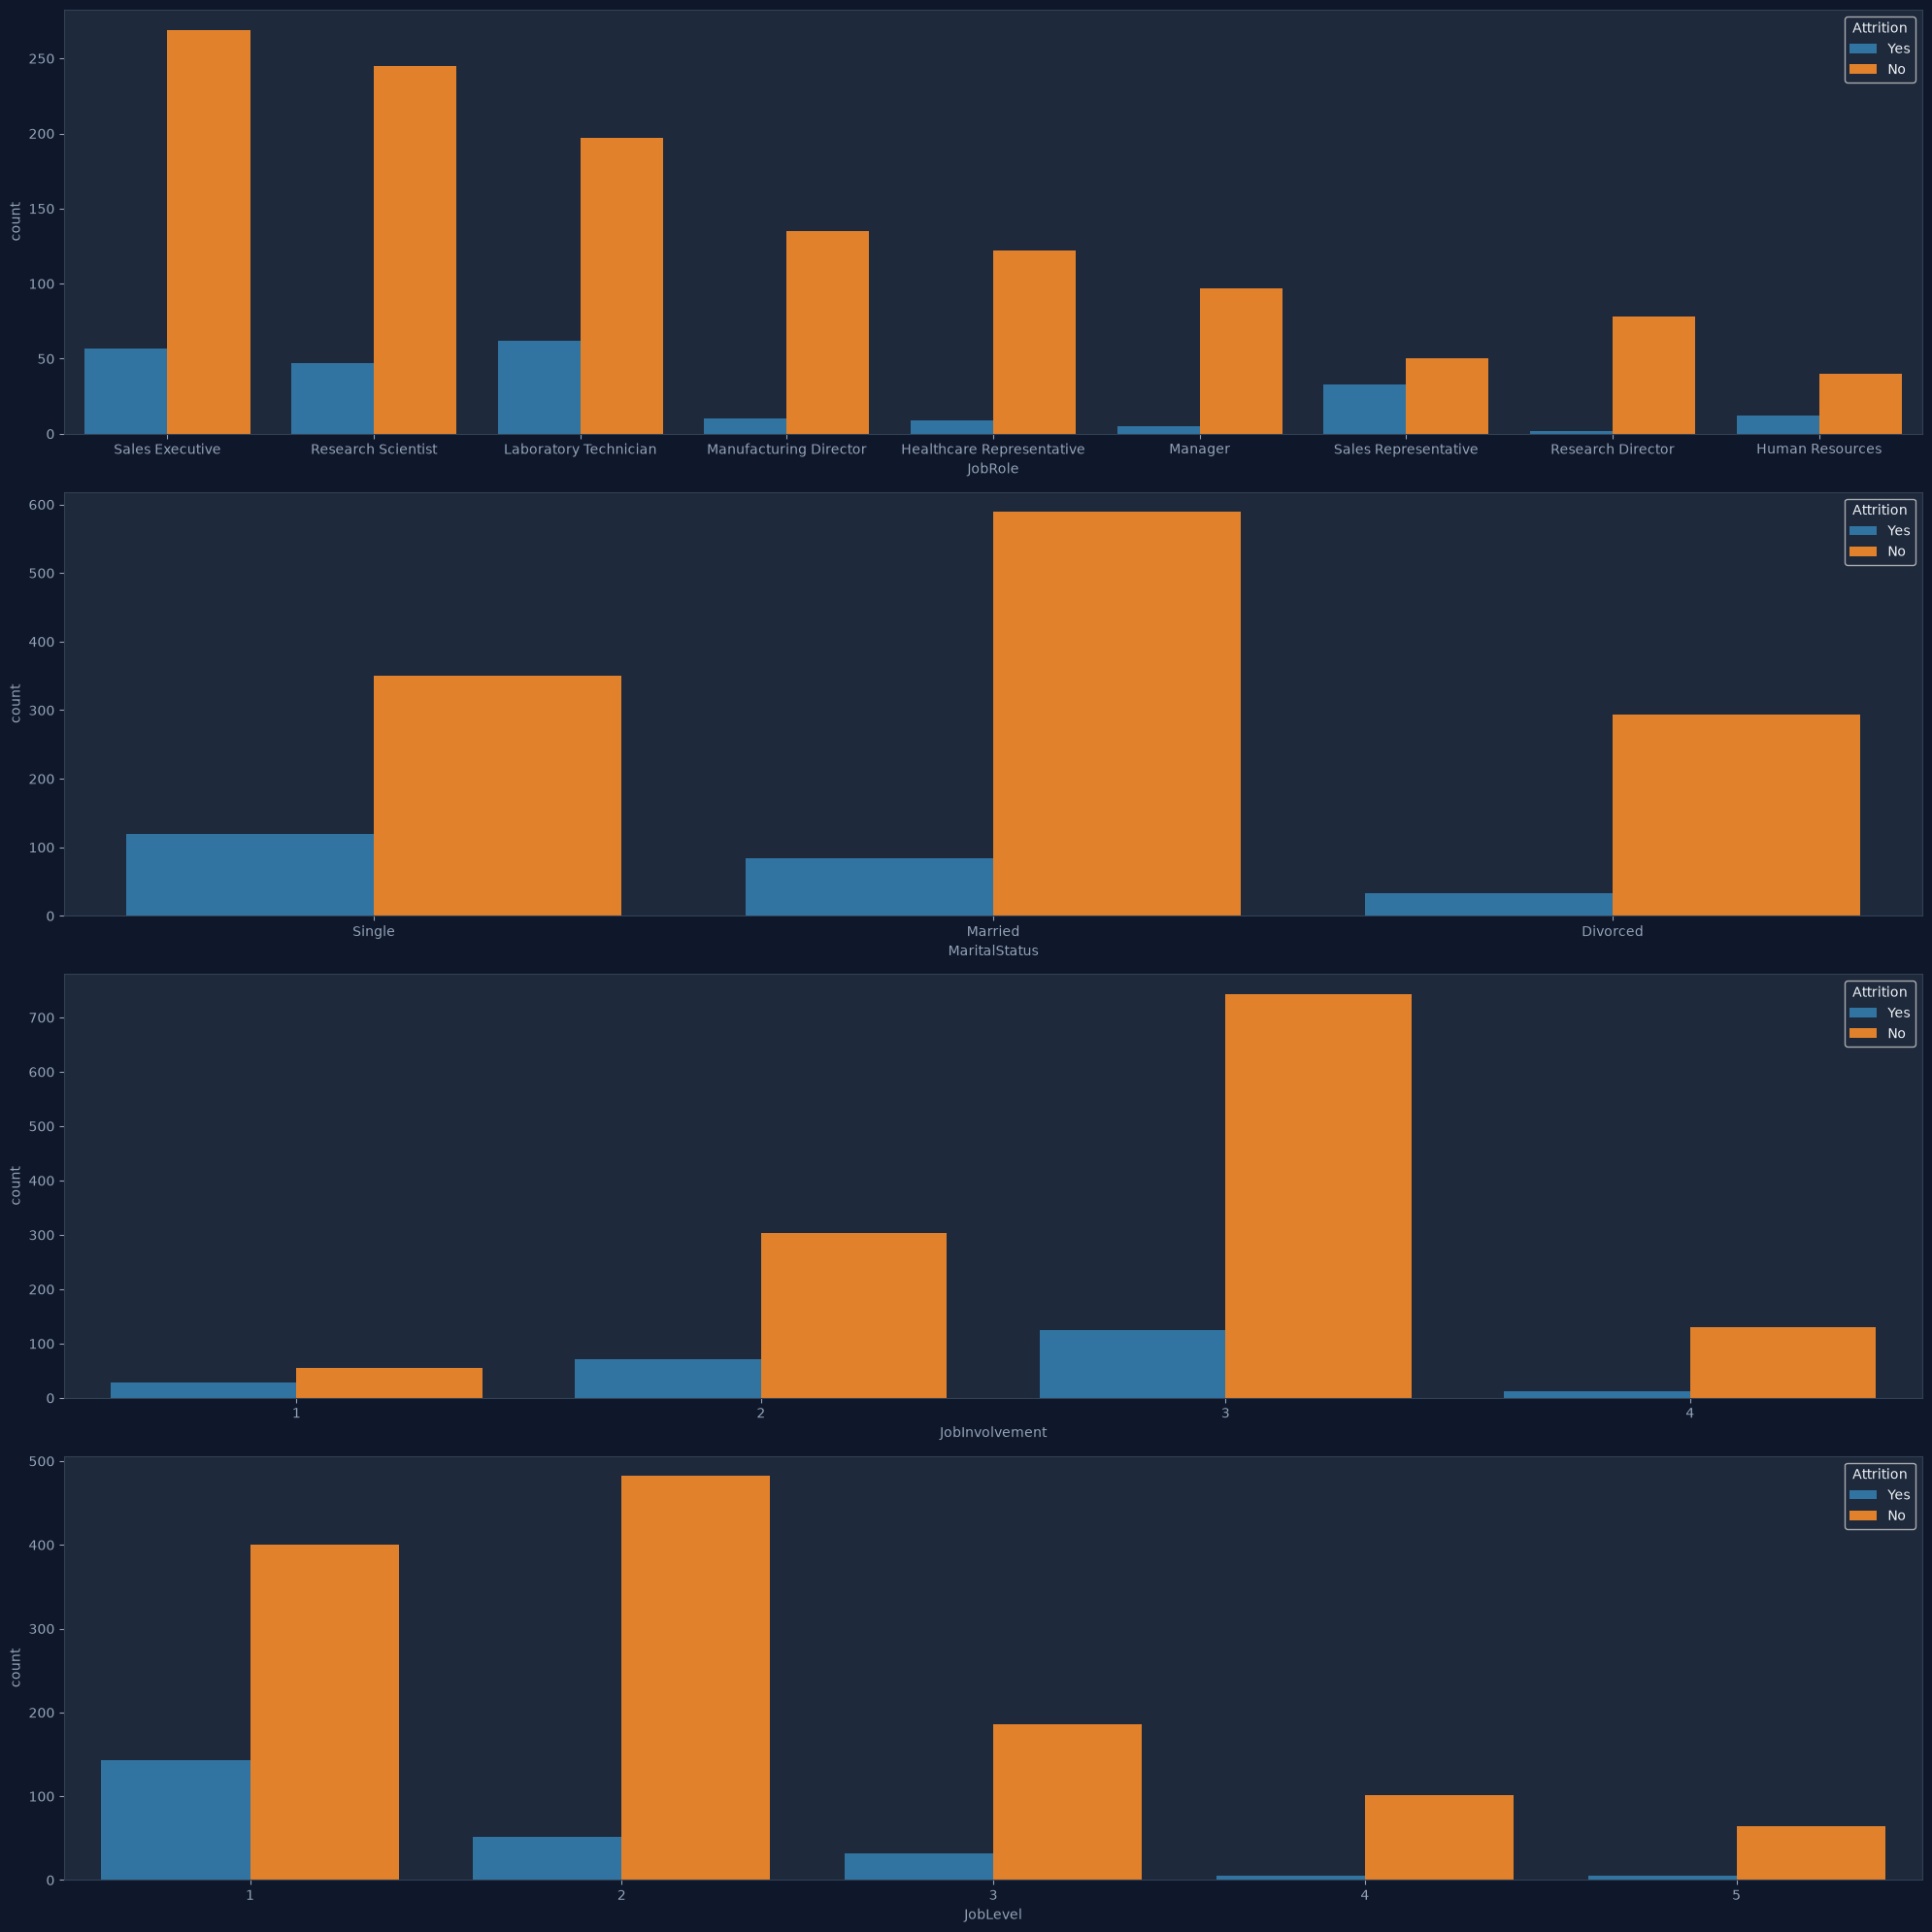

In [19]:
plt.figure(figsize=[20, 20])

plt.subplot(411)
sns.countplot(x='JobRole', hue='Attrition', data=employee_df)

plt.subplot(412)
sns.countplot(x='MaritalStatus', hue='Attrition', data=employee_df)

plt.subplot(413)
sns.countplot(x='JobInvolvement', hue='Attrition', data=employee_df)

plt.subplot(414)
sns.countplot(x='JobLevel', hue='Attrition', data=employee_df)

plt.tight_layout()
plt.show()

### 3.5 Distribuições comparativas entre quem saiu e quem ficou

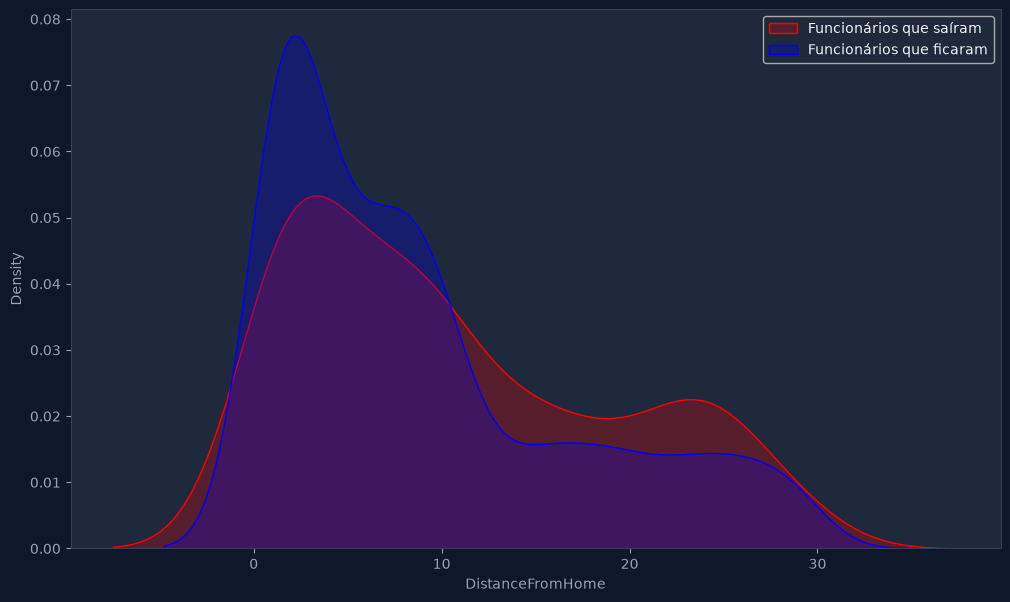

In [22]:
left_df = employee_df[employee_df['Attrition'] == 'Yes']
stayed_df = employee_df[employee_df['Attrition'] == 'No']

plt.figure(figsize=(12, 7))
sns.kdeplot(left_df['DistanceFromHome'], label='Funcionários que saíram', shade=True, color='r')
sns.kdeplot(stayed_df['DistanceFromHome'], label='Funcionários que ficaram', shade=True, color='b')
plt.legend()
plt.show()

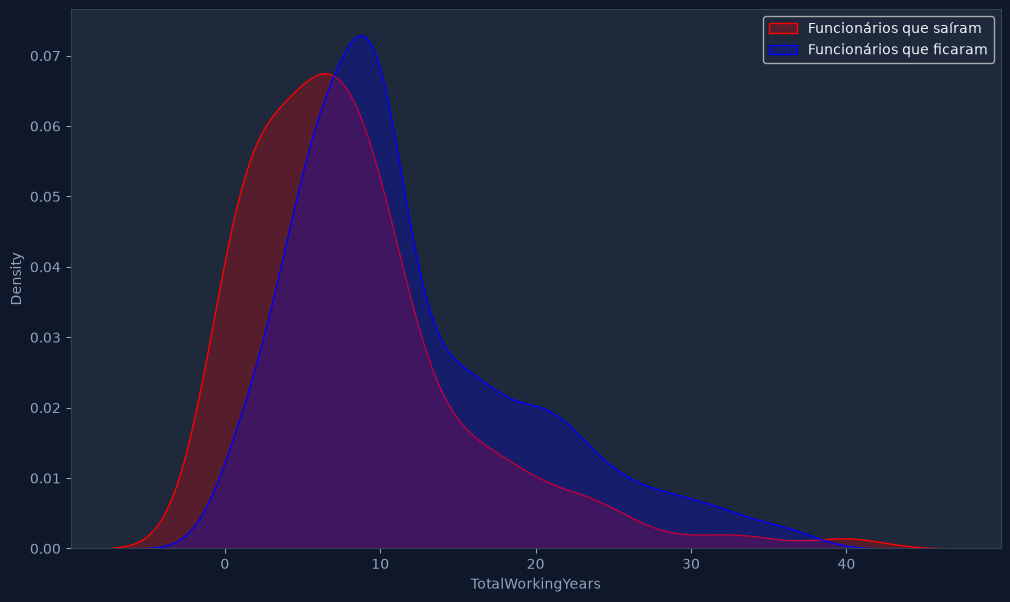

In [23]:
plt.figure(figsize=(12, 7))
sns.kdeplot(left_df['TotalWorkingYears'], label='Funcionários que saíram', shade=True, color='r')
sns.kdeplot(stayed_df['TotalWorkingYears'], label='Funcionários que ficaram', shade=True, color='b')
plt.legend()
plt.show()

### 3.6 Renda por gênero e por cargo

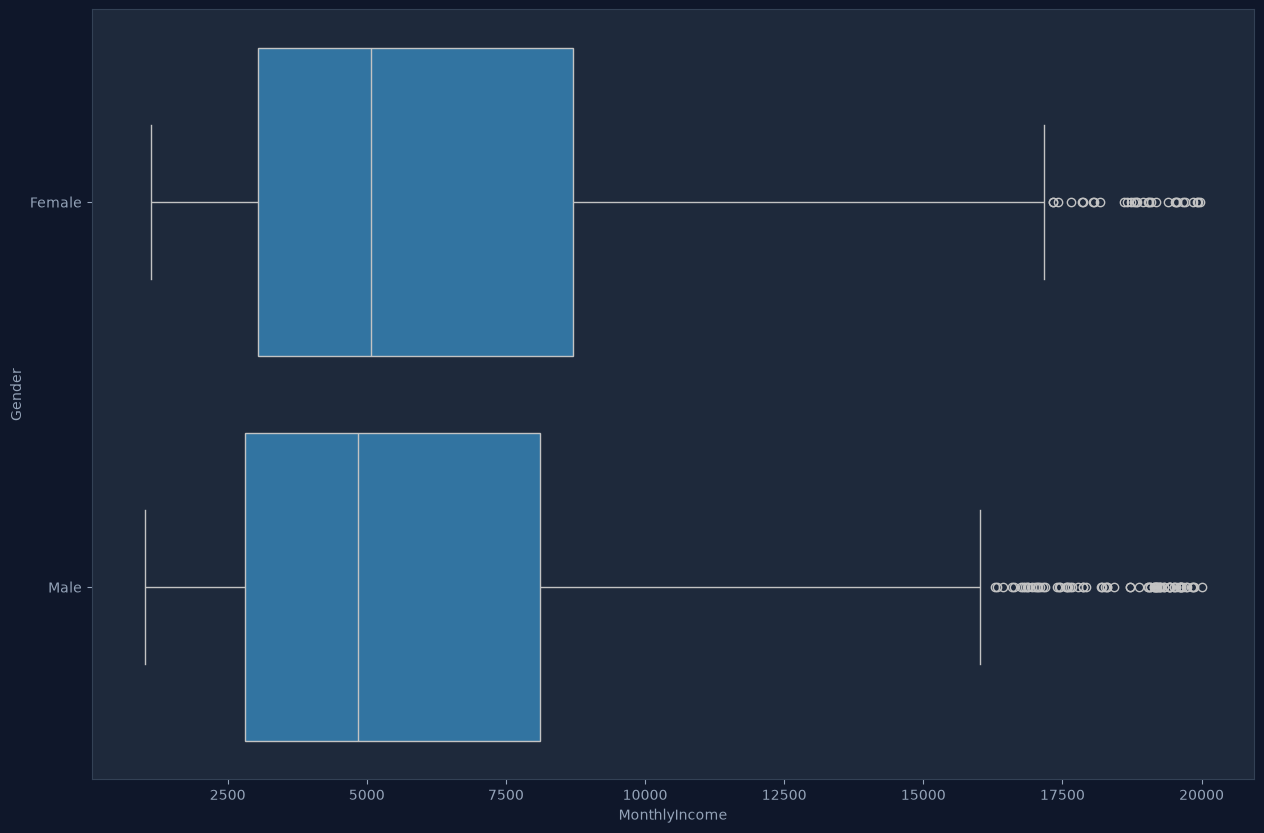

In [37]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='MonthlyIncome', 
            y='Gender',
            data=employee_df,
            linecolor='#c3c3c3',
           )
plt.show()

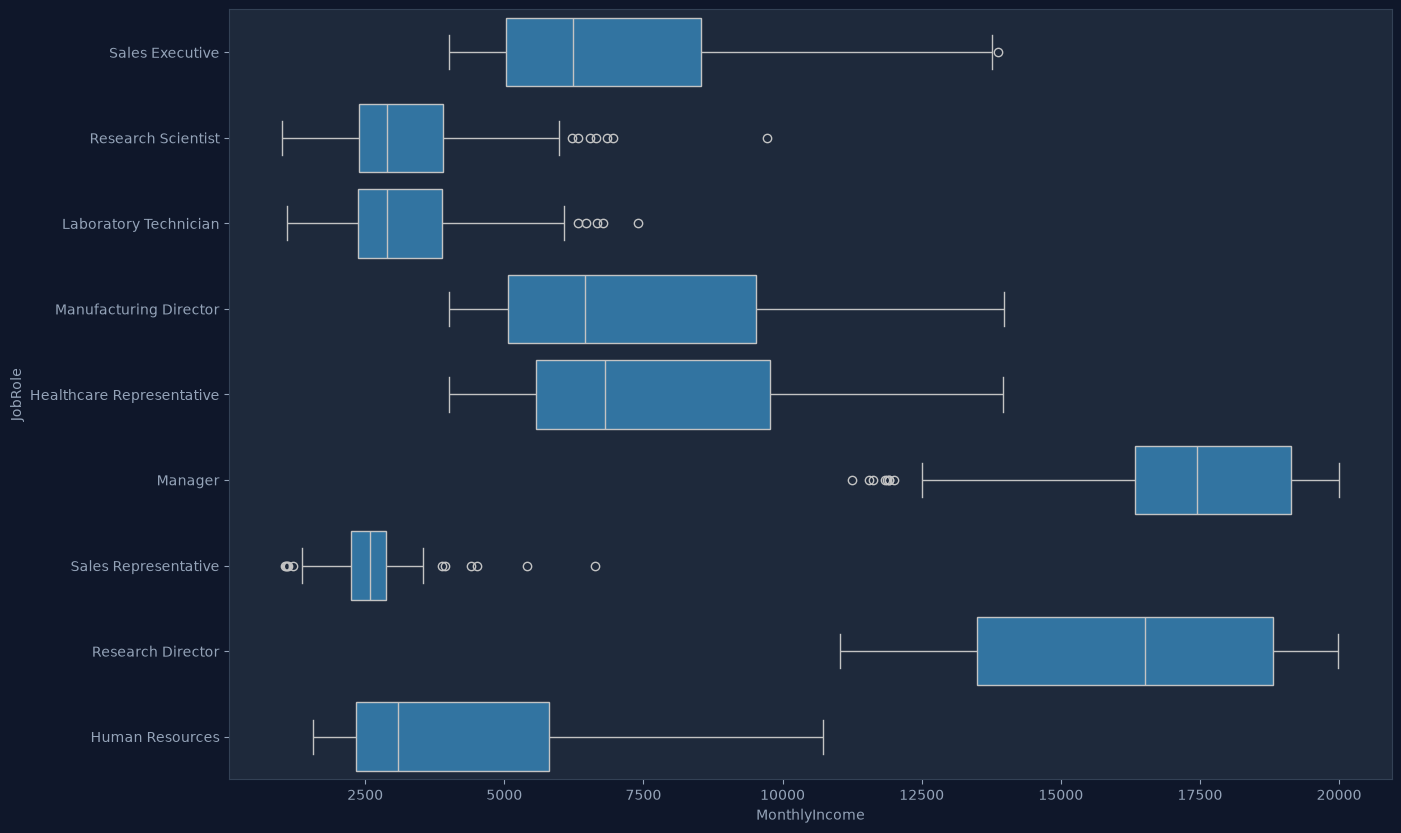

In [38]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='MonthlyIncome', y='JobRole', data=employee_df, linecolor='#c3c3c3',)
plt.show()

### 3.7 Resumo da análise exploratória

## 4. Tratamento e Limpeza dos Dados

### 4.1 Remoção de colunas constantes e identificadoras

In [19]:
antes = employee_df.shape[1]

employee_df.drop(
    ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'],
    axis=1,
    inplace=True
)

print(f"Colunas removidas: {antes - employee_df.shape[1]}")
print(f"Colunas restantes: {employee_df.shape[1]}")

Colunas removidas: 4
Colunas restantes: 31


### 4.2 Codificação das variáveis binárias

Converto as variáveis binárias para valores numéricos, tornando-as compatíveis com os algoritmos de Machine Learning. Como possuem apenas duas categorias, não há necessidade de aplicar One-Hot Encoding.

In [20]:
employee_df['Attrition'] = employee_df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

employee_df['OverTime'] = employee_df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

employee_df[['Attrition', 'OverTime']].head()

,Attrition,OverTime
0,1,1
1,0,0
2,1,1
3,0,1
4,0,0


### 4.3 Resumo do impacto acumulado

> Os atributos constantes foram removidos com sucesso nesta etapa e logo a seguir foi feito a codificação binária das categóricas simples.

## 5. Preparação para Modelagem

Nesta etapa preparo os dados para treinamento dos modelos. Diferentemente da limpeza realizada na seção anterior, as transformações aqui são ajustadas exclusivamente com o conjunto de treinamento, evitando vazamento de informação (*data leakage*) para o conjunto de teste.

### 5.1 Separação entre variáveis preditoras e variável alvo

Separo a variável alvo (`y`) das variáveis preditoras (`X`), garantindo que a resposta não participe das etapas de pré-processamento.

In [21]:
X = employee_df.drop(columns='Attrition')
y = employee_df['Attrition']

In [7]:
X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,41,...,3,3,1,17,3,3,5,2,0,3
1466,39,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,42,...,3,1,1,9,5,3,7,7,1,7
1467,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,87,...,4,2,1,6,0,3,6,2,0,3
1468,49,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,63,...,3,4,0,17,3,2,9,6,0,8


In [8]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

### 5.2 Separação entre treino e teste

Realizo a divisão dos dados antes de qualquer transformação. Dessa forma, todas as etapas de pré-processamento aprendem apenas com os dados de treinamento.

Utilizo `stratify=y` para preservar a proporção entre as classes e `random_state` para garantir a reprodutibilidade dos experimentos.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

X_train.shape, X_test.shape

((1102, 30), (368, 30))

### 5.3 Identificação das variáveis categóricas e numéricas

Identifico automaticamente quais atributos são categóricos e quais são numéricos utilizando `select_dtypes()`. Essa abordagem reduz dependências de listas escritas manualmente e torna o código mais reutilizável para outros conjuntos de dados.

In [23]:
colunas_categoricas = X_train.select_dtypes(
    include='object'
).columns

colunas_numericas = X_train.select_dtypes(
    include='number'
).columns

In [24]:
colunas_categoricas

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='str')

In [25]:
colunas_numericas

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

### 5.4 Pré-processamento com ColumnTransformer

Centralizo todas as transformações em um único objeto utilizando `ColumnTransformer`. As variáveis categóricas são codificadas com `OneHotEncoder`, enquanto as variáveis numéricas são normalizadas com `MinMaxScaler`.

O parâmetro `drop='first'` evita a armadilha da variável dummy, enquanto `handle_unknown='ignore'` garante que categorias não observadas durante o treinamento não provoquem erros durante a inferência.

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categoricas',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            colunas_categoricas
        ),
        (
            'numericas',
            MinMaxScaler(),
            colunas_numericas
        )
    ]
)

### 5.5 Aplicação do pré-processamento

Ajusto (`fit`) o pré-processador apenas utilizando o conjunto de treinamento. Em seguida aplico (`transform`) exatamente a mesma transformação ao conjunto de teste.

Esse procedimento impede vazamento de informação e garante uma avaliação mais confiável do desempenho dos modelos.

In [29]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

### 5.6 Verificação da distribuição das classes

Confirmo que a divisão estratificada preservou a proporção entre funcionários que permaneceram e que deixaram a empresa nos conjuntos de treinamento e teste.

In [30]:
print('Proporção de Attrition no treino:')
print(y_train.value_counts(normalize=True))

print('\nProporção de Attrition no teste:')
print(y_test.value_counts(normalize=True))

Proporção de Attrition no treino:
Attrition
0    0.838475
1    0.161525
Name: proportion, dtype: float64

Proporção de Attrition no teste:
Attrition
0    0.839674
1    0.160326
Name: proportion, dtype: float64


## 6. Treinamento dos Modelos

Treino quatro modelos de classificação (Regressão Logística, Random Forest, XGBoost e Rede Neural Artificial), cada um em duas versões: uma configuração base e outra com tratamento do desbalanceamento de classes. Essa estratégia permite avaliar o impacto do balanceamento sobre o desempenho de cada algoritmo.

### 6.1 Estratégia de tratamento do desbalanceamento de classes

Opto pela ponderação de classes em vez de técnicas de sobreamostragem, como o SMOTE, preservando a distribuição original dos dados. A estratégia adotada varia conforme o algoritmo:

- `class_weight='balanced'` para Regressão Logística e Random Forest;
- `scale_pos_weight` para XGBoost;
- `class_weight` manual durante o treinamento da Rede Neural.

In [31]:
peso_classe = (y_train == 0).sum() / (y_train == 1).sum()
peso_classe

np.float64(5.191011235955056)

### 6.2 Regressão Logística

A regressão logística é utilizada como modelo linear de referência para comparação com os algoritmos baseados em árvores e com a rede neural.

#### 6.2.1 Modelo base

In [32]:
logistic_base = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_base.fit(X_train, y_train)

y_pred_logistic_base = logistic_base.predict(X_test)

#### 6.2.2 Modelo balanceado

In [33]:
logistic_bal = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

logistic_bal.fit(X_train, y_train)

y_pred_logistic_bal = logistic_bal.predict(X_test)

#### 6.2.3 Interpretação dos coeficientes

Os coeficientes da regressão logística permitem interpretar o efeito de cada atributo sobre a probabilidade de rotatividade. Quanto maior o valor absoluto do coeficiente, maior a influência da variável na decisão do modelo.

In [34]:
feature_names = preprocessor.get_feature_names_out()

coeficientes = (
    pd.Series(
        logistic_bal.coef_[0],
        index=feature_names
    )
    .sort_values(key=np.abs, ascending=False)
)

coeficientes.head(10)

numericas__YearsSinceLastPromotion               1.790667
numericas__OverTime                              1.564060
categoricas__JobRole_Laboratory Technician       1.496968
numericas__TotalWorkingYears                    -1.477947
categoricas__BusinessTravel_Travel_Frequently    1.473720
numericas__YearsWithCurrManager                 -1.443776
numericas__NumCompaniesWorked                    1.384461
numericas__Age                                  -1.344898
categoricas__JobRole_Sales Representative        1.199440
numericas__JobInvolvement                       -1.123103
dtype: float64

### 6.3 Random Forest

O Random Forest é um método baseado em conjuntos de árvores de decisão, capaz de capturar relações não lineares entre as variáveis sem necessidade de pressupostos estatísticos sobre os dados.

#### 6.3.1 Modelo base

In [35]:
forest_base = RandomForestClassifier(
    random_state=RANDOM_STATE
)

forest_base.fit(X_train, y_train)

y_pred_forest_base = forest_base.predict(X_test)

#### 6.3.2 Modelo balanceado

In [36]:
forest_bal = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

forest_bal.fit(X_train, y_train)

y_pred_forest_bal = forest_bal.predict(X_test)

#### 6.3.3 Importância das variáveis

A importância das variáveis é calculada a partir da redução média da impureza proporcionada por cada atributo durante a construção das árvores.

In [37]:
importancia_forest = (
    pd.Series(
        forest_bal.feature_importances_,
        index=feature_names
    )
    .sort_values(ascending=False)
)

importancia_forest.head(10)

numericas__MonthlyIncome           0.067535
numericas__Age                     0.065673
numericas__OverTime                0.052600
numericas__DailyRate               0.052082
numericas__TotalWorkingYears       0.050268
numericas__YearsAtCompany          0.046231
numericas__DistanceFromHome        0.045061
numericas__HourlyRate              0.044118
numericas__MonthlyRate             0.043724
numericas__YearsWithCurrManager    0.039603
dtype: float64

### 6.4 XGBoost

O XGBoost implementa Gradient Boosting otimizado, construindo árvores sequencialmente para corrigir os erros das árvores anteriores e frequentemente apresentando elevado desempenho em problemas de classificação tabular.

#### 6.4.1 Modelo base

In [38]:
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)

#### 6.4.2 Modelo balanceado

In [39]:
xgb_bal = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    scale_pos_weight=peso_classe
)

xgb_bal.fit(X_train, y_train)

y_pred_xgb_bal = xgb_bal.predict(X_test)

#### 6.4.3 Importância das variáveis

Assim como no Random Forest, o XGBoost fornece medidas de importância que permitem identificar quais atributos mais contribuíram para as decisões do modelo.

In [40]:
importancia_xgb = (
    pd.Series(
        xgb_bal.feature_importances_,
        index=feature_names
    )
    .sort_values(ascending=False)
)

importancia_xgb.head(10)

categoricas__JobRole_Research Director     0.063655
categoricas__JobRole_Human Resources       0.061816
numericas__OverTime                        0.051576
numericas__YearsAtCompany                  0.048727
numericas__JobLevel                        0.047912
categoricas__JobRole_Sales Executive       0.043586
numericas__StockOptionLevel                0.037053
categoricas__Department_Sales              0.033379
numericas__JobInvolvement                  0.028838
categoricas__JobRole_Research Scientist    0.028023
dtype: float32

### 6.5 Rede Neural Artificial

Utilizo uma rede neural densa com três camadas ocultas, mantendo uma arquitetura próxima à proposta original do curso. O objetivo é comparar o desempenho da rede com os modelos lineares e baseados em árvores.

#### 6.5.1 Arquitetura da rede

In [41]:
def criar_rede_neural(input_dim):
    modelo = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(units=25, activation='relu'),
        tf.keras.layers.Dense(units=25, activation='relu'),
        tf.keras.layers.Dense(units=25, activation='relu'),
        tf.keras.layers.Dense(units=1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo


rede_neural_base = criar_rede_neural(X_train.shape[1])
rede_neural_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 25)                  │           1,125 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,451 (9.57 KB)

 Trainable params: 2,451 (9.57 KB)

 Non-trainable params: 0 (0.00 B)

#### 6.5.2 Modelo base

In [42]:
historico_base = rede_neural_base.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

y_pred_rede_base = (
    rede_neural_base.predict(X_test) >= 0.5
).astype(int).ravel()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


#### 6.5.3 Modelo balanceado

In [43]:
rede_neural_bal = criar_rede_neural(X_train.shape[1])

pesos_classe_dict = {
    0: 1.0,
    1: peso_classe
}

historico_bal = rede_neural_bal.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0,
    class_weight=pesos_classe_dict
)

y_pred_rede_bal = (
    rede_neural_bal.predict(X_test) >= 0.5
).astype(int).ravel()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


#### 6.5.4 Curva de aprendizado

Acompanho a evolução da perda e da acurácia durante o treinamento para verificar se a rede está aprendendo de forma consistente.

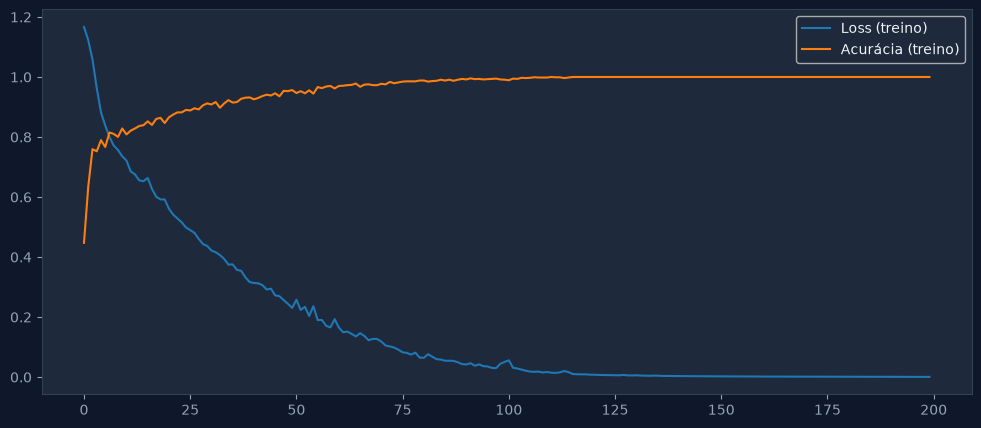

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(
    historico_bal.history['loss'],
    label='Loss (treino)'
)

plt.plot(
    historico_bal.history['accuracy'],
    label='Acurácia (treino)'
)

plt.legend()
plt.show()

### 6.6 Validação cruzada estratificada

Para reduzir a dependência de uma única divisão treino/teste, aplico validação cruzada estratificada de 5 folds nas versões balanceadas dos modelos baseados em scikit-learn e XGBoost.

As métricas reportadas são F1-score e ROC-AUC médios, juntamente com seus desvios padrão.

In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

modelos_cv = {
    'Regressão Logística': logistic_bal,
    'Random Forest': forest_bal,
    'XGBoost': xgb_bal
}

resultados_cv = {}

for nome, modelo in modelos_cv.items():
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=['f1', 'roc_auc']
    )

    resultados_cv[nome] = {
        'F1 médio': scores['test_f1'].mean(),
        'F1 desvio': scores['test_f1'].std(),
        'ROC-AUC médio': scores['test_roc_auc'].mean(),
        'ROC-AUC desvio': scores['test_roc_auc'].std()
    }

pd.DataFrame(resultados_cv).T

,F1 médio,F1 desvio,ROC-AUC médio,ROC-AUC desvio
Regressão Logística,0.518342,0.045307,0.840410,0.048068
Random Forest,0.419813,0.045889,0.792165,0.039018
XGBoost,0.471711,0.045886,0.802919,0.037420


## 7. Avaliação dos Modelos

Após o treinamento, comparo os modelos utilizando métricas adequadas para problemas de classificação desbalanceada. Além da acurácia, considero precisão, recall, F1-score, ROC-AUC e PR-AUC.

### 7.1 Métricas consolidadas

In [46]:
def calcular_metricas(y_true, y_pred, y_proba, nome):
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precisão': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba)
    }

In [47]:
probas = {
    'Regressão Logística (base)': logistic_base.predict_proba(X_test)[:, 1],
    'Regressão Logística (balanceada)': logistic_bal.predict_proba(X_test)[:, 1],
    'Random Forest (base)': forest_base.predict_proba(X_test)[:, 1],
    'Random Forest (balanceada)': forest_bal.predict_proba(X_test)[:, 1],
    'XGBoost (base)': xgb_base.predict_proba(X_test)[:, 1],
    'XGBoost (balanceado)': xgb_bal.predict_proba(X_test)[:, 1],
    'Rede Neural (base)': rede_neural_base.predict(X_test).ravel(),
    'Rede Neural (balanceada)': rede_neural_bal.predict(X_test).ravel()
}

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [48]:
preds = {
    'Regressão Logística (base)': y_pred_logistic_base,
    'Regressão Logística (balanceada)': y_pred_logistic_bal,
    'Random Forest (base)': y_pred_forest_base,
    'Random Forest (balanceada)': y_pred_forest_bal,
    'XGBoost (base)': y_pred_xgb_base,
    'XGBoost (balanceado)': y_pred_xgb_bal,
    'Rede Neural (base)': y_pred_rede_base,
    'Rede Neural (balanceada)': y_pred_rede_bal
}

In [49]:
tabela_metricas = pd.DataFrame([
    calcular_metricas(
        y_test,
        preds[nome],
        probas[nome],
        nome
    )
    for nome in preds
])

tabela_metricas

,Modelo,Acurácia,Precisão,Recall,F1,ROC-AUC,PR-AUC
0,Regressão Logística (base),0.877717,0.750000,0.355932,0.482759,0.816192,0.586297
1,Regressão Logística (balanceada),0.782609,0.393939,0.661017,0.493671,0.814327,0.561596
2,Random Forest (base),0.831522,0.400000,0.101695,0.162162,0.763151,0.420461
3,Random Forest (balanceada),0.842391,0.514286,0.305085,0.382979,0.746558,0.404535
4,XGBoost (base),0.842391,0.521739,0.203390,0.292683,0.750919,0.445165
5,XGBoost (balanceado),0.847826,0.548387,0.288136,0.377778,0.750315,0.465158
6,Rede Neural (base),0.839674,0.500000,0.372881,0.427184,0.687894,0.387710
7,Rede Neural (balanceada),0.812500,0.410714,0.389831,0.400000,0.742609,0.437241


### 7.2 Curvas ROC comparativas

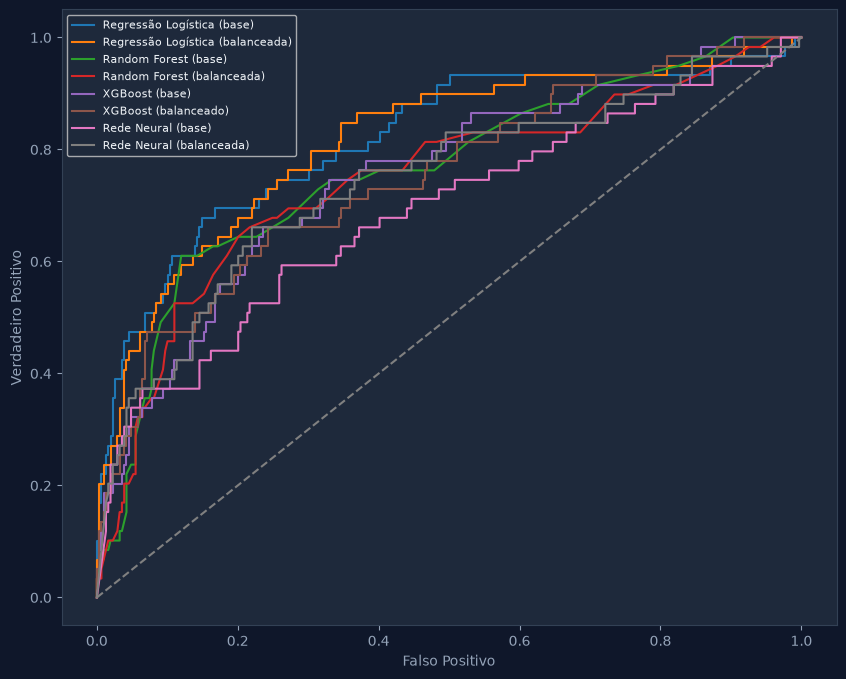

In [50]:
plt.figure(figsize=(10, 8))

for nome, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)

    plt.plot(
        fpr,
        tpr,
        label=nome
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.legend(fontsize=8)

plt.show()

### 7.3 Curvas Precisão-Recall comparativas

Como o problema apresenta desbalanceamento de classes, as curvas Precisão-Recall são especialmente úteis para avaliar o desempenho dos modelos na identificação da classe minoritária.

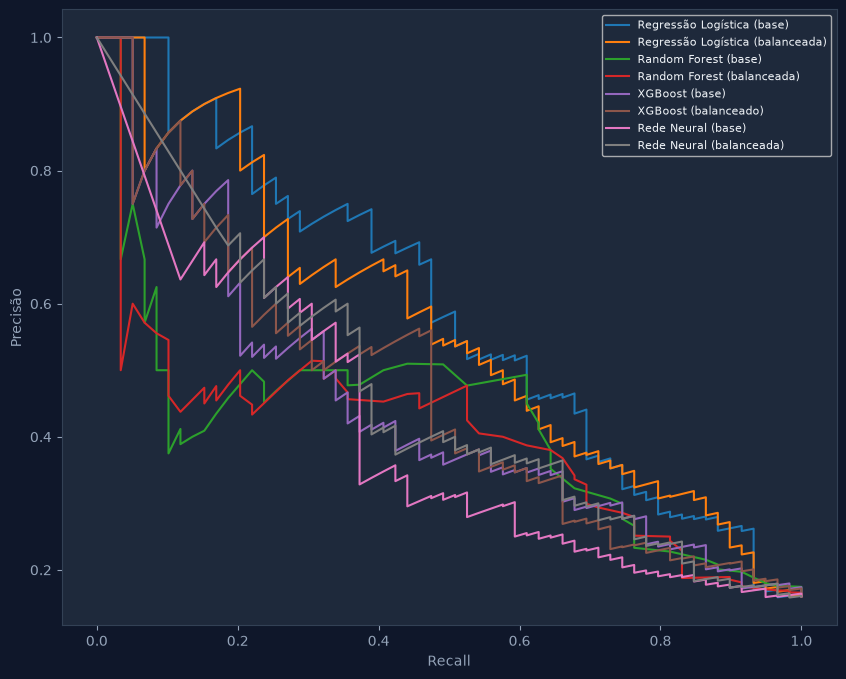

In [51]:
plt.figure(figsize=(10, 8))

for nome, proba in probas.items():
    precisao, recall, _ = precision_recall_curve(
        y_test,
        proba
    )

    plt.plot(
        recall,
        precisao,
        label=nome
    )

plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.legend(fontsize=8)

plt.show()

### 7.4 Matrizes de confusão

Utilizo `confusion_matrix(y_test, y_pred)` para todos os modelos, mantendo a ordem correta entre valores reais e previstos.

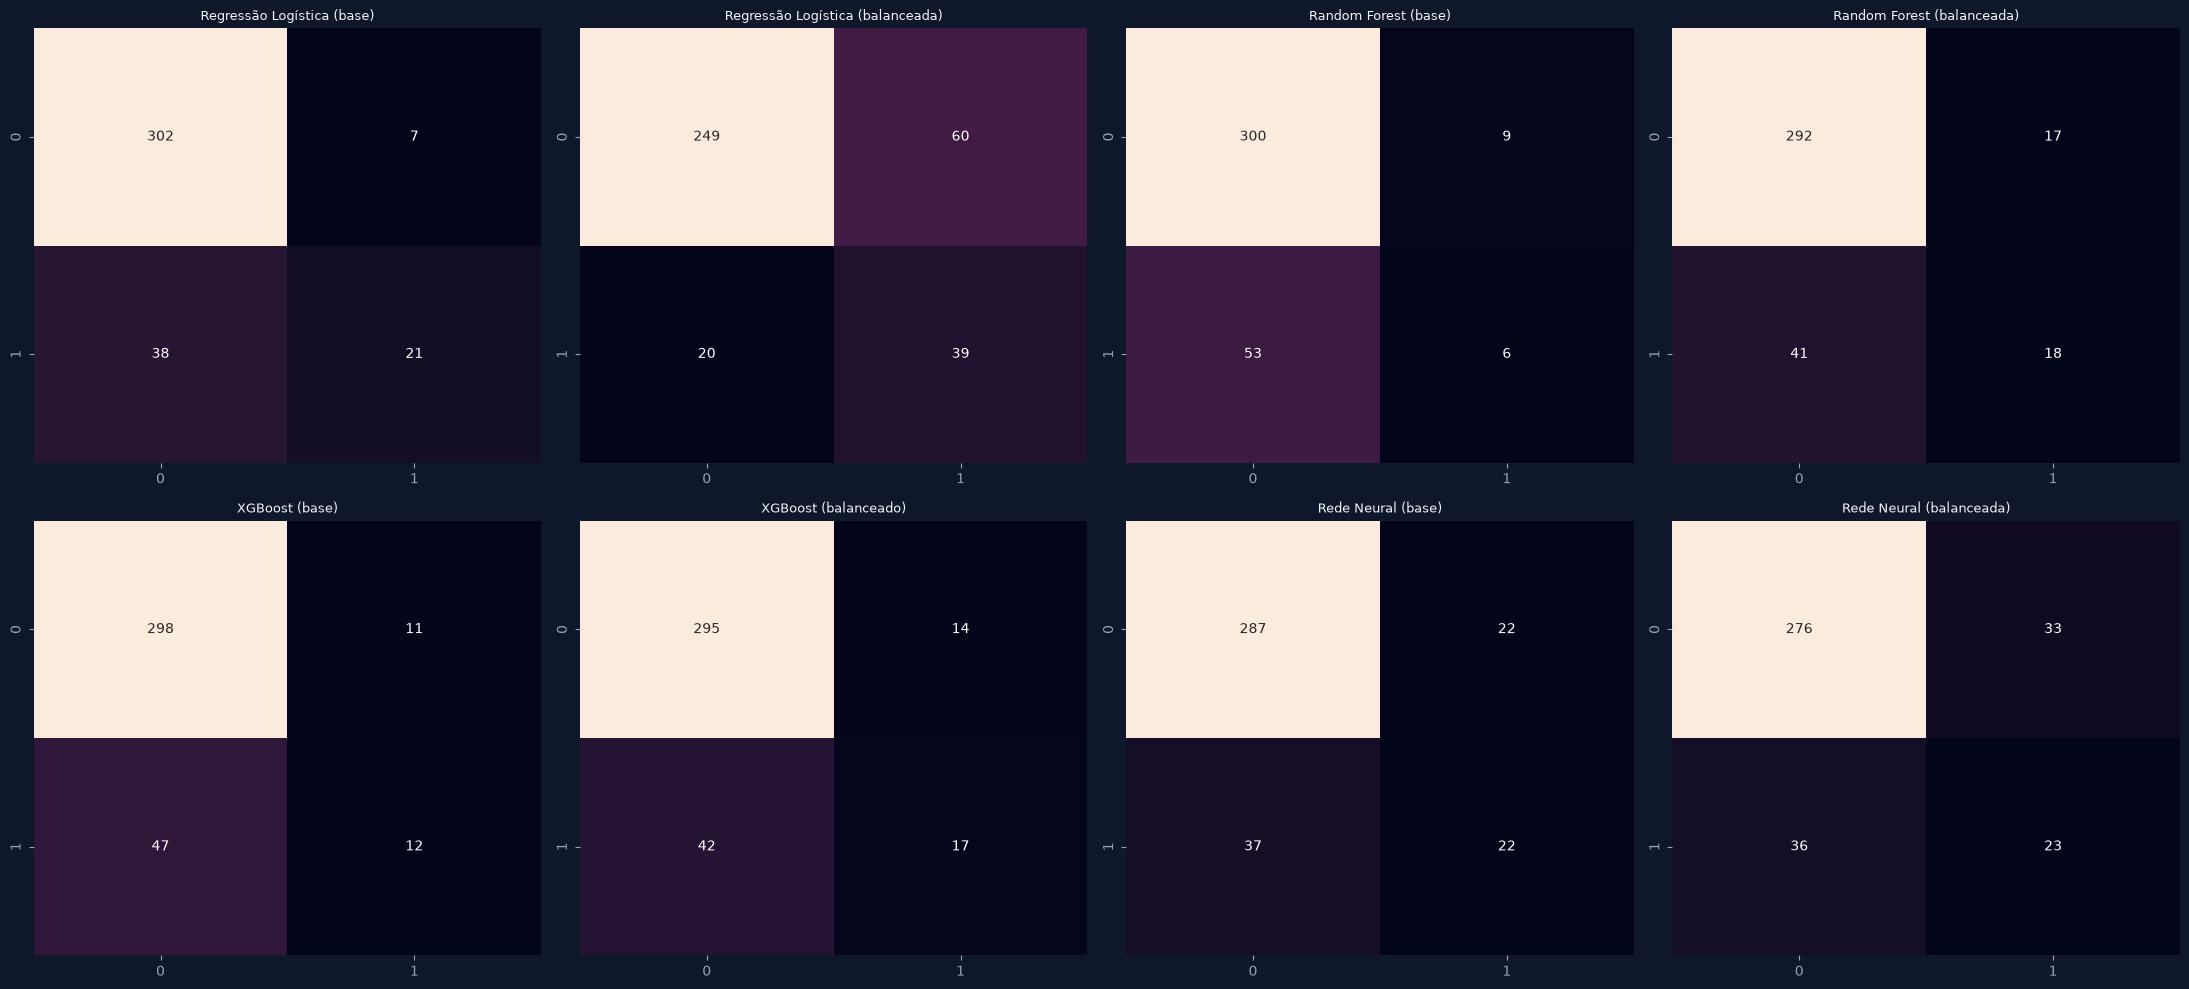

In [52]:
fig, eixos = plt.subplots(
    2,
    4,
    figsize=(22, 10)
)

for eixo, (nome, pred) in zip(eixos.ravel(), preds.items()):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cbar=False,
        ax=eixo
    )

    eixo.set_title(nome, fontsize=9)

plt.tight_layout()

plt.show()

### 7.5 Convergência entre modelos na importância de variáveis

In [53]:
comparacao_importancia = pd.DataFrame({
    'Random Forest': importancia_forest,
    'XGBoost': importancia_xgb,
    'Regressão Logística (coef. absoluto)': coeficientes.abs()
}).sort_values('Random Forest', ascending=False)

comparacao_importancia.head(10)

,Random Forest,XGBoost,Regressão Logística (coef. absoluto)
numericas__MonthlyIncome,0.067535,0.021787,0.312656
numericas__Age,0.065673,0.023956,1.344898
numericas__OverTime,0.052600,0.051576,1.564060
numericas__DailyRate,0.052082,0.017399,0.675663
numericas__TotalWorkingYears,0.050268,0.027137,1.477947
numericas__YearsAtCompany,0.046231,0.048727,0.274546
numericas__DistanceFromHome,0.045061,0.018094,0.977289
numericas__HourlyRate,0.044118,0.015535,0.369288
numericas__MonthlyRate,0.043724,0.013568,0.242769
numericas__YearsWithCurrManager,0.039603,0.026834,1.443776


Cruzando os top 10 de cada modelo, `OverTime` é a única variável presente nos três ao mesmo tempo: 3º lugar no Random Forest (0.0526), 3º no XGBoost (0.0516) e 2º na regressão logística, com coeficiente positivo de 1.5641. O sinal positivo confirma a direção esperada, funcionários que fazem hora extra têm maior probabilidade prevista de saída.

Outras seis variáveis aparecem em pelo menos dois dos três modelos, formando um segundo grupo ligado a tempo de casa e maturidade na carreira:

| Variável | Random Forest | XGBoost | Regressão Logística (coef.) |
|-|-|-|-|
| OverTime | 0.0526 (3º) | 0.0516 (3º) | 1.5641 (2º) |
| Age | 0.0657 (2º) | não aparece | -1.3449 (8º) |
| TotalWorkingYears | 0.0503 (5º) | não aparece | -1.4779 (4º) |
| YearsAtCompany | 0.0462 (6º) | 0.0487 (4º) | não aparece |
| YearsWithCurrManager | 0.0396 (10º) | não aparece | -1.4438 (6º) |
| JobInvolvement | não aparece | 0.0288 (9º) | -1.1231 (10º) |

Nenhuma dessas variáveis, isoladamente, tinha correlação forte com o alvo na Seção 3.2 (a maior foi TotalWorkingYears, com -0.171), o que indica que a previsão depende da combinação de fatores, não de uma única variável dominante.

### 7.6 Escolha do modelo final

Escolho a regressão logística balanceada como modelo final. Os quatro modelos com melhor ROC-AUC no teste são os dois da regressão logística (0.8162 base e 0.8143 balanceada), à frente de random forest (0.7466 a 0.7632), XGBoost (0.7503 a 0.7509) e rede neural (0.6879 a 0.7426). Isso se confirma na validação cruzada da Seção 6.6, onde a regressão logística tem o maior F1 médio (0.5183) e o maior ROC-AUC médio (0.8404) entre os três modelos avaliados, com desvio padrão comparável aos demais.

Entre as duas versões da regressão logística, prefiro a balanceada. O ROC-AUC e o PR-AUC caem muito pouco em relação à base (0.8143 contra 0.8162, e 0.5616 contra 0.5863), o que mostra que a capacidade de ranquear os funcionários por risco é praticamente a mesma. A diferença está no recall, que quase dobra, de 0.3559 para 0.6610, ao custo de precisão menor, de 0.7500 para 0.3939. Para o problema de negócio, deixar de identificar um funcionário que vai sair custa mais do que iniciar uma conversa de retenção com alguém que ficaria, o que justifica priorizar recall.

---

## 8. Conclusão e Considerações Finais

### 8.1 Síntese do Projeto

Parti do case de Recursos Humanos do curso Ciência de Dados para Empresas e Negócios e ampliei o escopo original em três frentes, tratamento de desbalanceamento de classes, comparação robusta entre quatro modelos com validação cruzada, e interpretação cruzada de variáveis relevantes. O dataset tem 1470 registros e 16,12% de attrition, confirmando o desbalanceamento que motivou o projeto. A regressão logística balanceada foi escolhida como modelo final, superando random forest, XGBoost e rede neural em ROC-AUC tanto no teste quanto na validação cruzada.

| Modelo | Acurácia | Precisão | Recall | F1 | ROC-AUC |
|-|-|-|-|-|-|
| Regressão Logística (balanceada) | 0.7826 | 0.3939 | 0.6610 | 0.4937 | 0.8143 |
| Random Forest (balanceada) | 0.8424 | 0.5143 | 0.3051 | 0.3830 | 0.7466 |
| XGBoost (balanceado) | 0.8478 | 0.5484 | 0.2881 | 0.3778 | 0.7503 |
| Rede Neural (balanceada) | 0.8125 | 0.4107 | 0.3898 | 0.4000 | 0.7426 |

### 8.2 Achados relevantes

O efeito do balanceamento de classes variou muito entre os algoritmos. No random forest, o recall triplicou, de 0.1017 para 0.3051, mostrando que sem ponderação o modelo praticamente ignorava a classe minoritária. No XGBoost o ganho foi de 0.2034 para 0.2881. Na rede neural o efeito foi pequeno, de 0.3729 para 0.3898. Na regressão logística, o recall quase dobrou, de 0.3559 para 0.6610, o maior ganho absoluto entre os quatro modelos.

`OverTime` foi a única variável convergente entre os três modelos interpretáveis (Random Forest, XGBoost e regressão logística), com direção consistente, hora extra associada a maior probabilidade de saída. Isso reforça esse atributo como o sinal de risco mais robusto encontrado no projeto, por não depender de um único algoritmo para aparecer.

### 8.3 Limitações e Considerações

Este projeto não explora sobreamostragem sintética (SMOTE) como alternativa à ponderação de classes, nem ajuste fino de hiperparâmetros via grid ou random search. A arquitetura da rede neural foi mantida próxima à original do curso, sem busca sistemática por número de camadas ou neurônios. A multicolinearidade identificada na Seção 3.3, como a correlação de 0.95 entre JobLevel e MonthlyIncome, não foi tratada de forma explícita, ficando sob a mitigação padrão da regularização L2 da regressão logística. Nenhuma variável isolada teve correlação forte com o alvo, o que limita o poder preditivo de qualquer um dos quatro modelos. Serialização do modelo para produção e construção de uma API de inferência também ficam fora do escopo. O dataset é sintético, gerado pela IBM para fins didáticos, o que limita a generalização das conclusões para contextos organizacionais reais. Este projeto tem finalidade educacional e de composição de portfólio.

---

## 9. Referências

- Dataset: [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset)
- [Quantas camadas escondidas e quantos neurônios incluir numa rede neural artificial (IAExpert Academy)](https://iaexpert.academy/2020/05/04/quantas-camadas-escondidas-e-quantos-neuronios-incluir-numa-rede-neural-artificial/)
- [scikit-learn: precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
- [scikit-learn: recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
- [scikit-learn: f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [scikit-learn: StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- [Documentação XGBoost](https://xgboost.readthedocs.io/)
- Curso: [Ciência de Dados para Empresas e Negócios (IAExpert Academy)](https://iaexpert.academy/cursos-online-assinatura/ciencia-de-dados-para-empresas-e-negocios/), seção Recursos Humanos

---

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Ciência de Dados para Empresas e Negócios](https://iaexpert.academy/cursos-online-assinatura/ciencia-de-dados-para-empresas-e-negocios/), para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.